In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/fully_cleaned.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10025 entries, 0 to 10024
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   JobTitle             10025 non-null  object 
 1   Company Size         10025 non-null  object 
 2   company_Industry     10025 non-null  object 
 3   Country              10025 non-null  object 
 4   Remote Type          10025 non-null  object 
 5   Exp. Level           10025 non-null  object 
 6   Years_Experience     10025 non-null  float64
 7   Education  Level     10025 non-null  object 
 8   Skills - Python      10025 non-null  int64  
 9   Skills - SQL         10025 non-null  int64  
 10  Skills - ML          10025 non-null  int64  
 11  Skills-DeepLearning  10025 non-null  int64  
 12  skills_Cloud         10025 non-null  int64  
 13  Salary (USD)         10025 non-null  float64
 14  Posting Month        10025 non-null  int64  
 15  posting_Year         10025 non-null 

In [ ]:
df.rename(columns={})

In [ ]:
df.head(1)

,JobTitle,Company Size,company_Industry,Country,Remote Type,Exp. Level,Years_Experience,Education Level,Skills - Python,Skills - SQL,Skills - ML,Skills-DeepLearning,skills_Cloud,Salary (USD),Posting Month,posting_Year,Hiring Urgency,Job Openings
0,Data Analyst,Start-up,Finance,Unknown,Hybrid,Junior,4.0,Bachelor's,1,1,0,0,0,61640.0,10,2024,Low,0


In [ ]:
df.shape

(10025, 18)

In [ ]:
df.columns

Index(['JobTitle', 'Company Size', 'company_Industry', 'Country',
       'Remote Type', 'Exp. Level', 'Years_Experience', 'Education  Level',
       'Skills - Python', 'Skills - SQL', 'Skills - ML', 'Skills-DeepLearning',
       'skills_Cloud', 'Salary (USD)', 'Posting Month', 'posting_Year',
       'Hiring Urgency', 'Job Openings'],
      dtype='object')

In [ ]:
# how does salary vary across experience levels
df.groupby('Years_Experience')['Salary (USD)'].mean().sort_values(ascending=False)

,Salary (USD)
Years_Experience,
2.9,177554.00
7.5,165180.50
0.5,164573.25
14.3,160092.20
5.2,156921.50
...,...
13.1,75329.50
8.6,71723.00
13.4,69074.50


In [ ]:
# does higher education level significantly increase salary
df.groupby('Education  Level')['Salary (USD)'].mean().sort_values(ascending=False)

,Salary (USD)
Education Level,
Master's,117273.113399
Unknown,116343.144399
Bachelor's,115891.156137
Ph.D,115629.562500


In [ ]:
# which industries pay the highest salaries
df.groupby('company_Industry')['Salary (USD)'].mean().sort_values(ascending=False)

,Salary (USD)
company_Industry,
Unknown,118306.024408
IT,117216.780261
Retail,116792.678715
Education,116111.037884
Finance,115922.466144
E-commerce,115411.524888
Healthcare,115339.411670


In [ ]:
# how does salary differ across countries
df.groupby('Country')['Salary (USD)'].mean().sort_values(ascending=False)

,Salary (USD)
Country,
Canada,117841.686692
Australia,117011.771756
United State America,116621.555752
Singapore,116617.642012
Unknown,116183.738462
Germany,115530.260748
United Kingdom,115524.924367
India,114813.446510


In [ ]:
# does remote work affect salary distribution
df.groupby('Remote Type')['Salary (USD)'].mean().sort_values(ascending=False)

,Salary (USD)
Remote Type,
Unknown,117979.524858
Onsite,116596.203571
Hybrid,116129.628288
Remote,115738.763125


In [ ]:
# salary difference between companies of different sizes
df.groupby('Company Size')['Salary (USD)'].mean().sort_values(ascending=False)

,Salary (USD)
Company Size,
Large,120403.559075
Unknown,115104.659559
Start-up,112572.451133
Medium,112072.375273


In [ ]:
# is there a salary premium for ml vs non-ml roles
df.groupby('Skills - ML')['Salary (USD)'].mean().sort_values(ascending=False)

,Salary (USD)
Skills - ML,
1,120939.914447
0,110024.107126


In [ ]:
# does deep learning skill increase salary significantly
df.groupby('Skills-DeepLearning')['Salary (USD)'].mean().sort_values(ascending=False)

,Salary (USD)
Skills-DeepLearning,
1,122812.038166
0,111379.130412


In [ ]:
# impact of cloud skills on salary
df.groupby('skills_Cloud')['Salary (USD)'].mean().sort_values(ascending=False)

,Salary (USD)
skills_Cloud,
1,118729.345356
0,112999.363976


In [ ]:
# salary trend over years(Posting year)
df.groupby('posting_Year')['Salary (USD)'].mean().sort_values(ascending=False)

,Salary (USD)
posting_Year,
2021,117401.322323
2024,117128.803831
2026,116476.690542
2025,116215.260991
2023,116101.181383
2020,115907.825963
2022,114665.266482


Skiils analysis

In [ ]:
df.columns

Index(['JobTitle', 'Company Size', 'company_Industry', 'Country',
       'Remote Type', 'Exp. Level', 'Years_Experience', 'Education  Level',
       'Skills - Python', 'Skills - SQL', 'Skills - ML', 'Skills-DeepLearning',
       'skills_Cloud', 'Salary (USD)', 'Posting Month', 'posting_Year',
       'Hiring Urgency', 'Job Openings'],
      dtype='object')

In [ ]:
# which skill combination yields highest salary
skill_cols = [
    'Skills - Python',
    'Skills - SQL',
    'Skills - ML',
    'Skills-DeepLearning',
    'skills_Cloud'
]

df['Skill_Combination'] = df[skill_cols].astype(str).agg('-'.join, axis=1)

skill_salary = (
    df.groupby('Skill_Combination')['Salary (USD)'].mean().sort_values(ascending=False).reset_index()
)

skill_salary.head(10)

,Skill_Combination,Salary (USD)
0,1-1-1-1-1,131166.091304
1,0-0-1-1-1,131119.913433
2,1-0-1-1-1,130400.717899
3,0-1-1-1-1,130361.358889
4,0-0-1-1-0,128107.807393
5,1-1-1-1-0,126826.467078
6,1-0-1-1-0,125596.107500
7,0-1-1-1-0,121187.203655
8,1-0-0-1-1,119999.457672
9,0-0-1-0-1,119523.419318


In [ ]:
# most demanded skill overall
df[skill_cols].sum().sort_values(ascending=False)

,0
Skills - ML,5745
skills_Cloud,5739
Skills - SQL,5711
Skills-DeepLearning,4297
Skills - Python,4226


In [ ]:
# are ml jobs requiring python + sql always
ml_jobs = df[df['Skills - ML'] == 1]
python_sql_required = ((ml_jobs['Skills - SQL'] == 1) & (ml_jobs['Skills - Python'] == 1)).mean() * 100
print(python_sql_required )

23.951261966927763


In [ ]:
# skills vs hiring urgency relationship
pd.crosstab(df['Hiring Urgency'],
            df['Skills - ML'])

Skills - ML,0,1
Hiring Urgency,,
High,1594,2387
Low,1608,2053
Medium,1078,1305


In [ ]:
# skill co-occurence(Python+ML, ML+DL)
df[skill_cols].corr()

,Skills - Python,Skills - SQL,Skills - ML,Skills-DeepLearning,skills_Cloud
Skills - Python,1.000000,-0.001408,0.001314,0.005558,0.015413
Skills - SQL,-0.001408,1.000000,0.007825,0.010220,0.012067
Skills - ML,0.001314,0.007825,1.000000,0.003068,-0.013384
Skills-DeepLearning,0.005558,0.010220,0.003068,1.000000,-0.004033
skills_Cloud,0.015413,0.012067,-0.013384,-0.004033,1.000000


In [ ]:
# skills vs job openings correlation
for skill in skill_cols:
  corr = df[skill].corr(df['Job Openings'])
  print(skill, corr)

Skills - Python -0.002107898726732405
Skills - SQL 0.017287622434239074
Skills - ML 0.015449069666357665
Skills-DeepLearning 0.028836282363785916
skills_Cloud 0.012354058498924897


In [ ]:
# which industries demand deep learning most
df.groupby('company_Industry')['Skills-DeepLearning'].sum().sort_values(ascending=False)

,Skills-DeepLearning
company_Industry,
Finance,702
E-commerce,678
IT,669
Education,659
Healthcare,638
Retail,636
Unknown,315


In [ ]:
# skill requirement by experience level
df.groupby('Exp. Level')[skill_cols].mean()

,Skills - Python,Skills - SQL,Skills - ML,Skills-DeepLearning,skills_Cloud
Exp. Level,,,,,
Fresher,0.437037,0.570370,0.562963,0.444444,0.555556
Junior,0.421631,0.584359,0.576040,0.434276,0.578369
Mid-level,0.428849,0.565330,0.566947,0.427555,0.568564
Senior,0.415246,0.562239,0.577999,0.422966,0.566420
Unknown,0.413743,0.558480,0.567251,0.431287,0.595029


Job Market Trends

In [ ]:
# which country hast the highesy job openings
df.groupby('Country')['Job Openings'].sum().sort_values(ascending=False)

,Job Openings
Country,
United State America,6432
Singapore,6077
United Kingdom,6023
Australia,5970
India,5867
Canada,5855
Germany,5649
Unknown,3346


In [ ]:
# remote vs on-site job distribution
df['Remote Type'].value_counts()

,count
Remote Type,
Remote,3162
Onsite,3080
Hybrid,3079
Unknown,704


In [ ]:
# hiring urgency trends across industries
pd.crosstab(df['company_Industry'], df['Hiring Urgency'])

Hiring Urgency,High,Low,Medium
company_Industry,,,
E-commerce,630,593,344
Education,590,567,374
Finance,641,592,362
Healthcare,584,576,391
IT,629,594,388
Retail,625,513,356
Unknown,282,226,168


In [ ]:
# job openings vs company size
df.groupby('Company Size')['Job Openings'].mean().sort_values(ascending=False).reset_index()

,Company Size,Job Openings
0,Medium,4.556575
1,Unknown,4.519118
2,Start-up,4.506711
3,Large,4.488870


In [ ]:
# monthly hiring trends
df.groupby('Posting Month')['Job Openings'].sum().reset_index()

,Posting Month,Job Openings
0,1,7607
1,2,3495
2,3,3384
3,4,3526
4,5,3287
5,6,3492
6,7,3152
7,8,3480
8,9,3364
9,10,3402


In [ ]:
# year-wise job growth trend
df.groupby('posting_Year')['Job Openings'].sum().sort_values(ascending=False).reset_index()

,posting_Year,Job Openings
0,2024,6725
1,2022,6596
2,2026,6540
3,2021,6535
4,2025,6397
5,2020,6289
6,2023,6137


In [ ]:
# industry-wise hiring patterns
df.groupby('company_Industry')['Job Openings'].sum().sort_values(ascending=False).reset_index()

,company_Industry,Job Openings
0,IT,7466
1,Finance,7170
2,E-commerce,7032
3,Healthcare,6860
4,Education,6840
5,Retail,6709
6,Unknown,3142


company insights

In [ ]:
# do large companies hire more ml engineers
df.groupby('Company Size')['Job Openings'].sum().sort_values(ascending=False).reset_index()

,Company Size,Job Openings
0,Large,20972
1,Start-up,10744
2,Medium,10430
3,Unknown,3073


In [ ]:
# company size vs salary distribution
df.groupby('Company Size')['Salary (USD)'].describe()

,count,mean,std,min,25%,50%,75%,max
Company Size,,,,,,,,
Large,4672.0,120694.093108,35111.162524,61004.0,95875.00,115587.0,141357.25,212076.75
Medium,2289.0,112401.580821,34472.412040,61004.0,88076.00,112172.0,128539.00,212076.75
Start-up,2384.0,112915.740038,35273.885225,61004.0,87637.50,113568.0,130366.25,212076.75
Unknown,680.0,115455.892279,36145.029440,61004.0,90013.75,113873.0,133177.75,212076.75


In [ ]:
# industry vs remote flexibility
pd.crosstab(df['company_Industry'], df['Remote Type'])

Remote Type,Hybrid,Onsite,Remote,Unknown
company_Industry,,,,
E-commerce,490,474,491,112
Education,463,475,487,106
Finance,488,477,491,139
Healthcare,473,472,517,89
IT,498,516,488,109
Retail,464,449,476,105
Unknown,203,217,212,44


In [ ]:
# do startups offer higher salaries
df.groupby('Company Size')['Salary (USD)'].mean().sort_values(ascending=False).reset_index()

,Company Size,Salary (USD)
0,Large,120694.093108
1,Unknown,115455.892279
2,Start-up,112915.740038
3,Medium,112401.580821


In [ ]:
# hiring urgency vs company size
pd.crosstab(df['Hiring Urgency'], df['Company Size'])

Company Size,Large,Medium,Start-up,Unknown
Hiring Urgency,,,,
High,1841,907,932,301
Low,1698,849,876,238
Medium,1133,533,576,141


UNIVARIATE ANALYSIS

<Axes: ylabel='Density'>

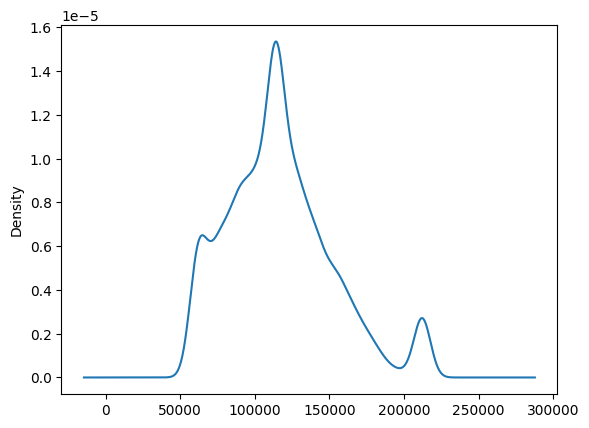

In [ ]:
# distribution of salary
df['Salary (USD)'].plot(kind='kde')
# it's not normally distributed

<Axes: >

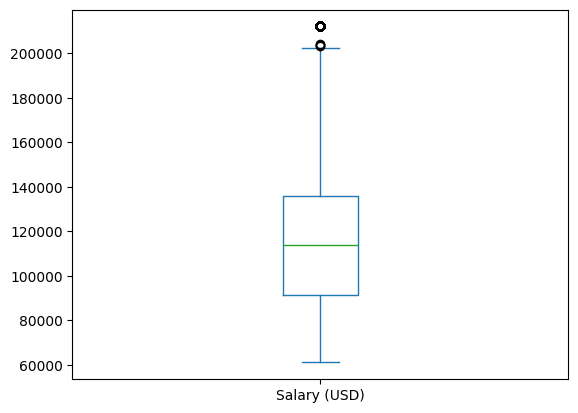

In [ ]:
# outliers in salary
df['Salary (USD)'].plot(kind='box')

<Axes: ylabel='Density'>

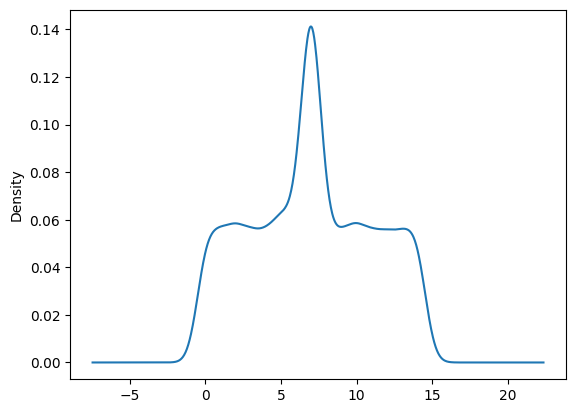

In [ ]:
# years of experience distribution
df['Years_Experience'].plot(kind='kde')

<Axes: ylabel='Density'>

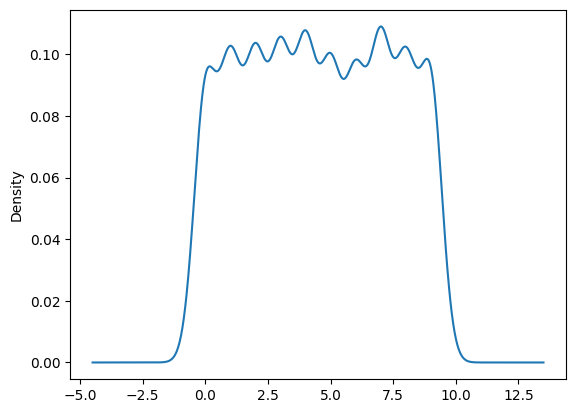

In [ ]:
# job openings distribution
df['Job Openings'].plot(kind='kde')

In [ ]:
# salary skewness
df['Salary (USD)'].skew()

np.float64(0.6672067122796873)

In [ ]:
# salary kurtosis
df['Salary (USD)'].kurt()

np.float64(0.3674538515611223)

<Axes: xlabel='JobTitle'>

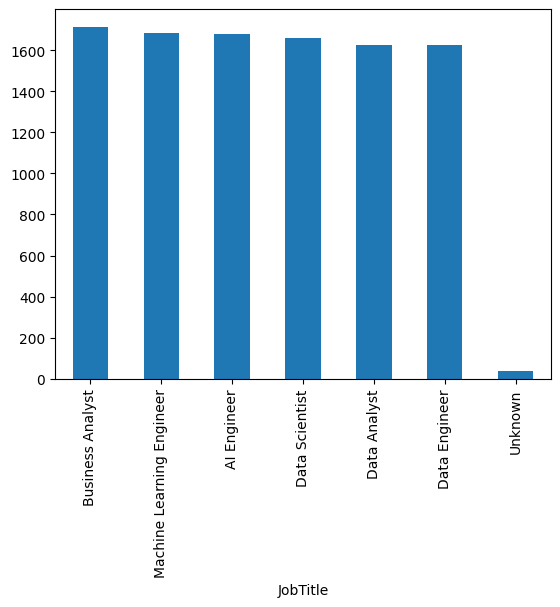

In [ ]:
# count of job titles
# df['JobTitle'].value_counts()
df['JobTitle'].value_counts().plot(kind='bar')

<Axes: xlabel='Company Size', ylabel='count'>

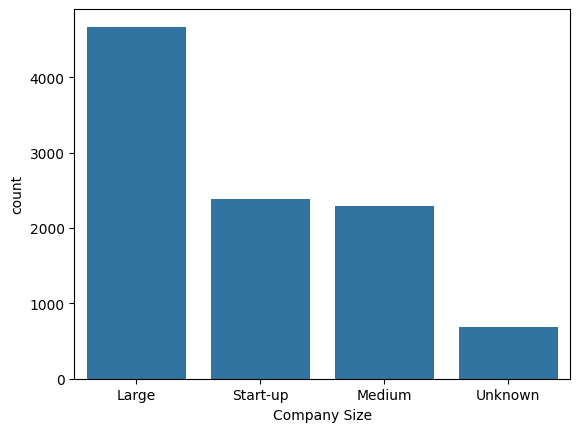

In [ ]:
# company size distribution
sns.barplot(df['Company Size'].value_counts())

<Axes: xlabel='company_Industry'>

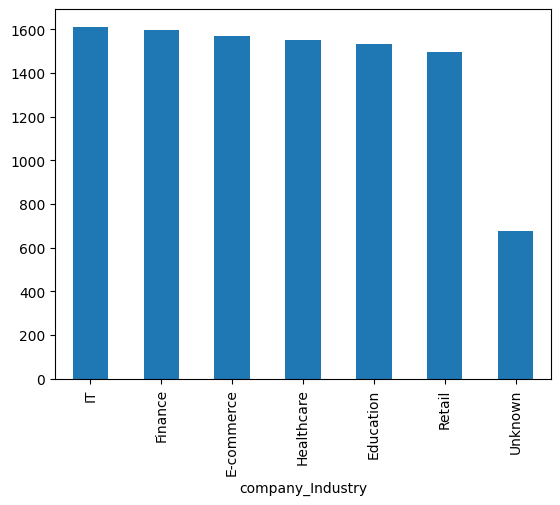

In [ ]:
# industry distribution
df['company_Industry'].value_counts().plot(kind='bar')

<Axes: xlabel='Country'>

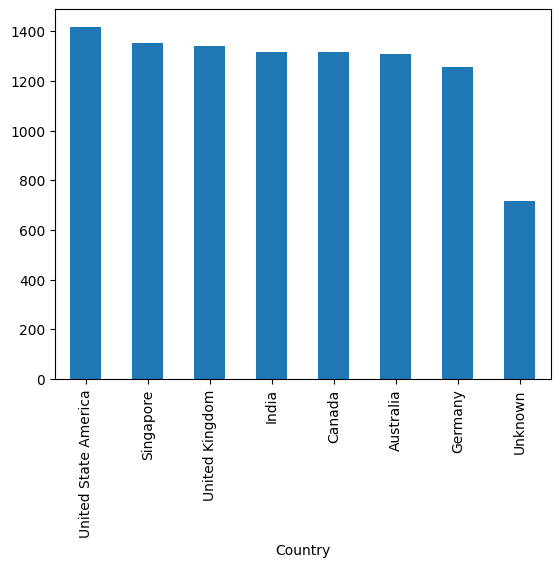

In [ ]:
# country frequency
df['Country'].value_counts().plot(kind='bar')

In [ ]:
# remote type proportions

<Axes: xlabel='Exp. Level', ylabel='count'>

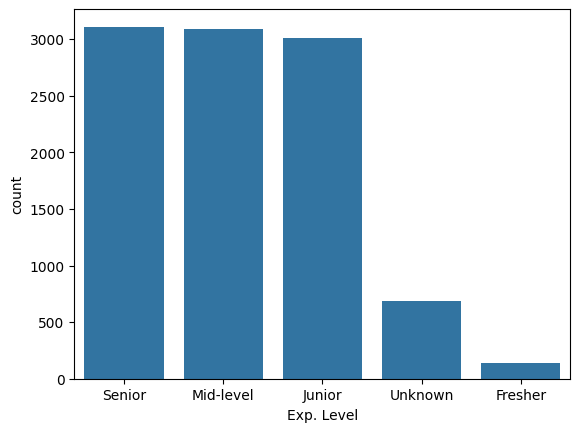

In [ ]:
# experience level distribution
sns.barplot(df['Exp. Level'].value_counts())

<Axes: xlabel='Education  Level', ylabel='count'>

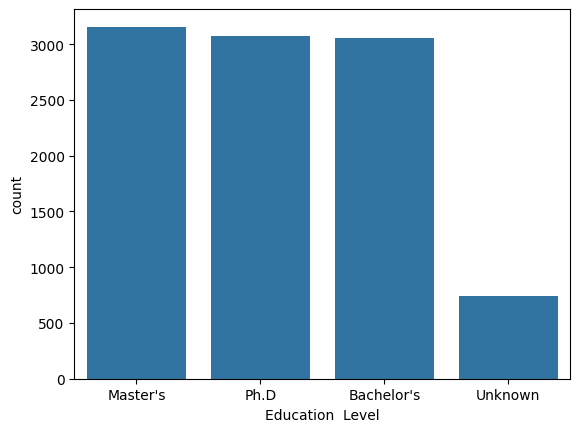

In [ ]:
# education level counts
sns.barplot(df['Education  Level'].value_counts())

<Axes: xlabel='Posting Month'>

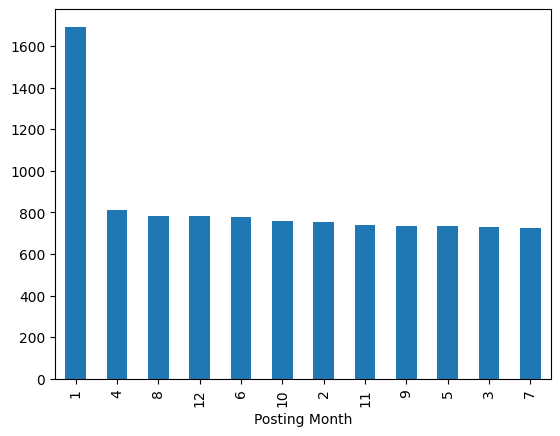

In [ ]:
# posting month trends
df['Posting Month'].value_counts().plot(kind='bar')

In [ ]:
# hiring urgency categories
df['Hiring Urgency'].value_counts()

,count
Hiring Urgency,
High,3981
Low,3661
Medium,2383


BIVARIATE ANALYSIS

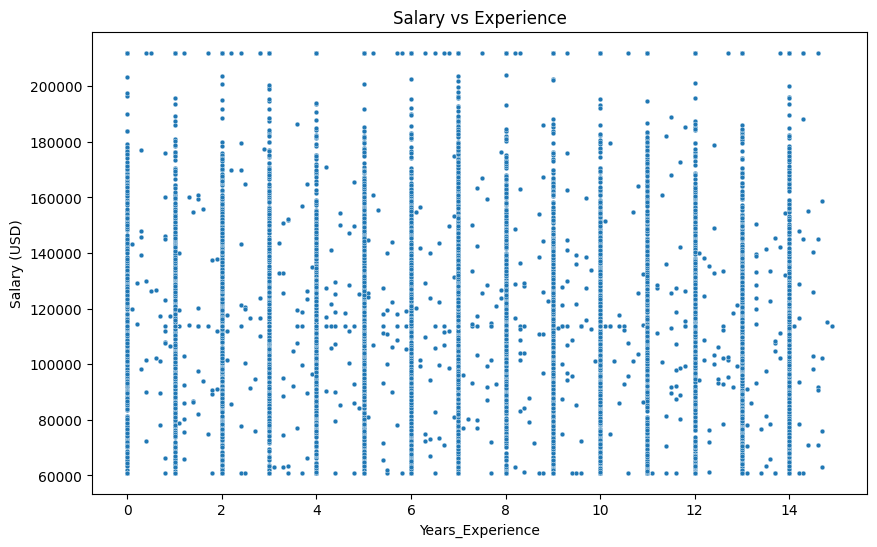

In [ ]:
# salary vs experince
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Years_Experience',
    y='Salary (USD)',
    s=12
)
plt.title("Salary vs Experience")
plt.show()

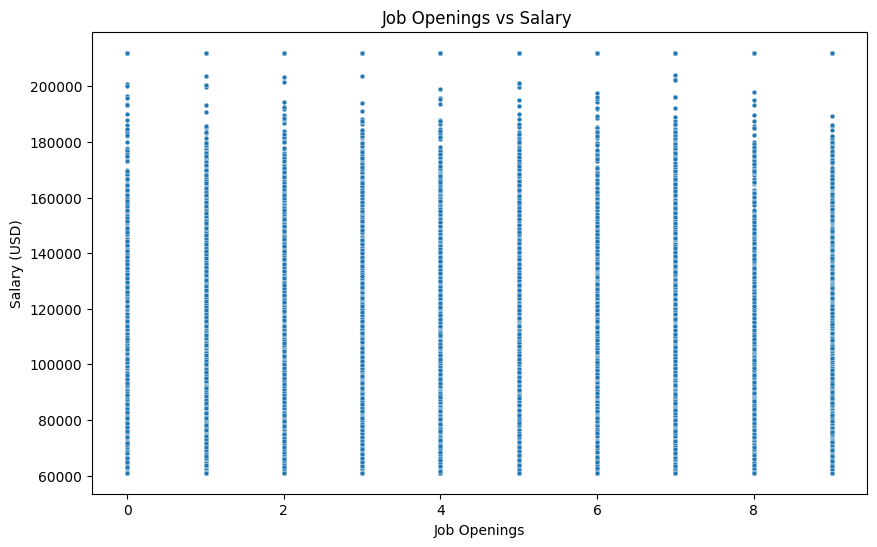

In [ ]:
# job openings vs salary
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Job Openings',
    y='Salary (USD)',
    s=12
)
plt.title("Job Openings vs Salary ")
plt.show()

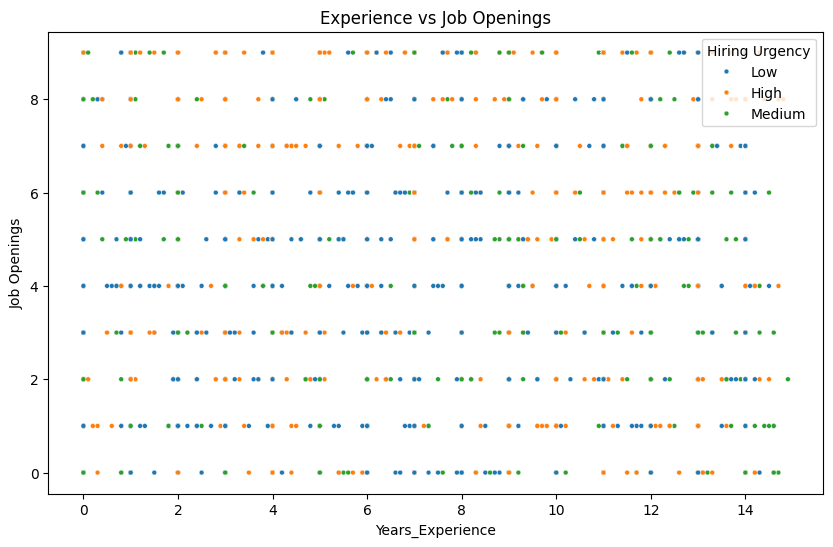

In [ ]:
# experience vs job openings
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Years_Experience',
    y='Job Openings',
    hue = 'Hiring Urgency',
    s=12
)
plt.title("Experience vs Job Openings")
plt.show()

Numerical - Categorical

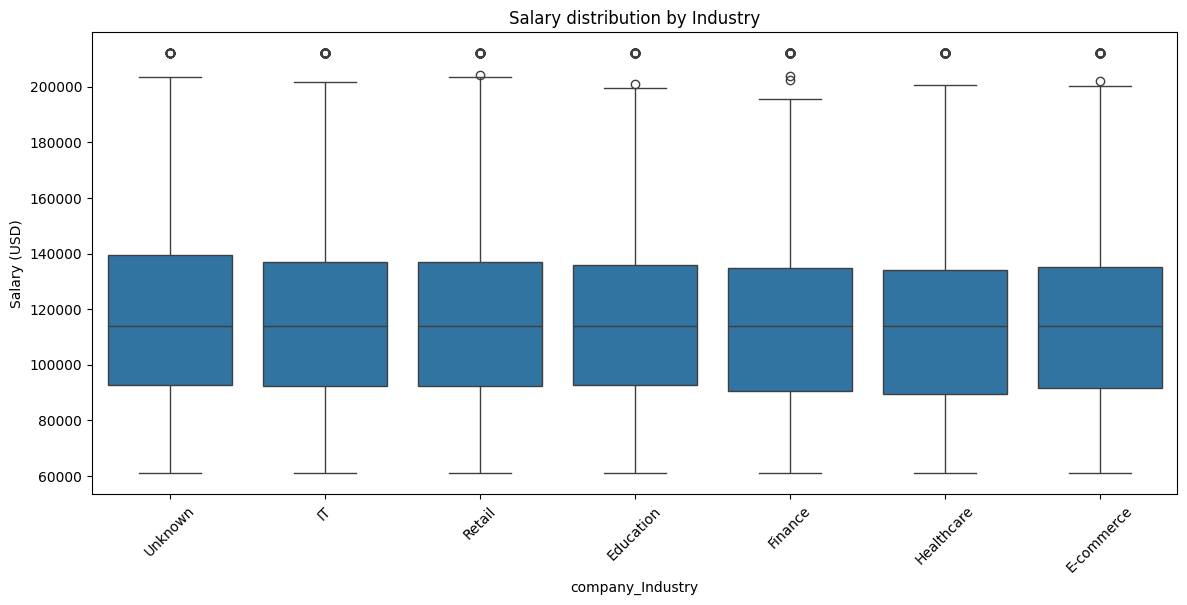

In [ ]:
# salary vs industry
plt.figure(figsize=(14,6))
industry_salary = df.groupby('company_Industry')['Salary (USD)'].mean().sort_values(ascending=False)

sns.boxplot(
          data=df,
          x = 'company_Industry',
          y= 'Salary (USD)',
          order = industry_salary.index)

plt.xticks(rotation=45)
plt.title("Salary distribution by Industry")
plt.show()

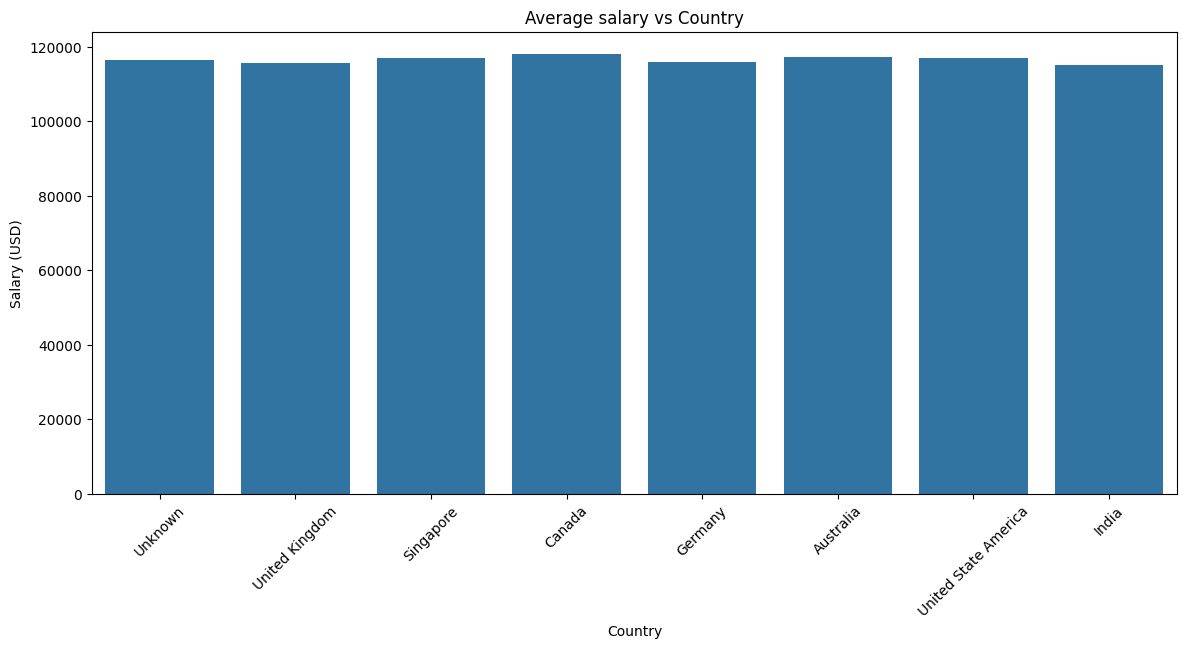

In [ ]:
# salary vs country
country_salary = df.groupby('Country')['Salary (USD)'].agg(['mean','median','max']).sort_values(by='median', ascending=False)

plt.figure(figsize=(14,6))
sns.barplot(
    data = df,
    x = 'Country',
    y = 'Salary (USD)',
    errorbar = None
)

plt.xticks(rotation=45)
plt.title("Average salary vs Country")
plt.show()

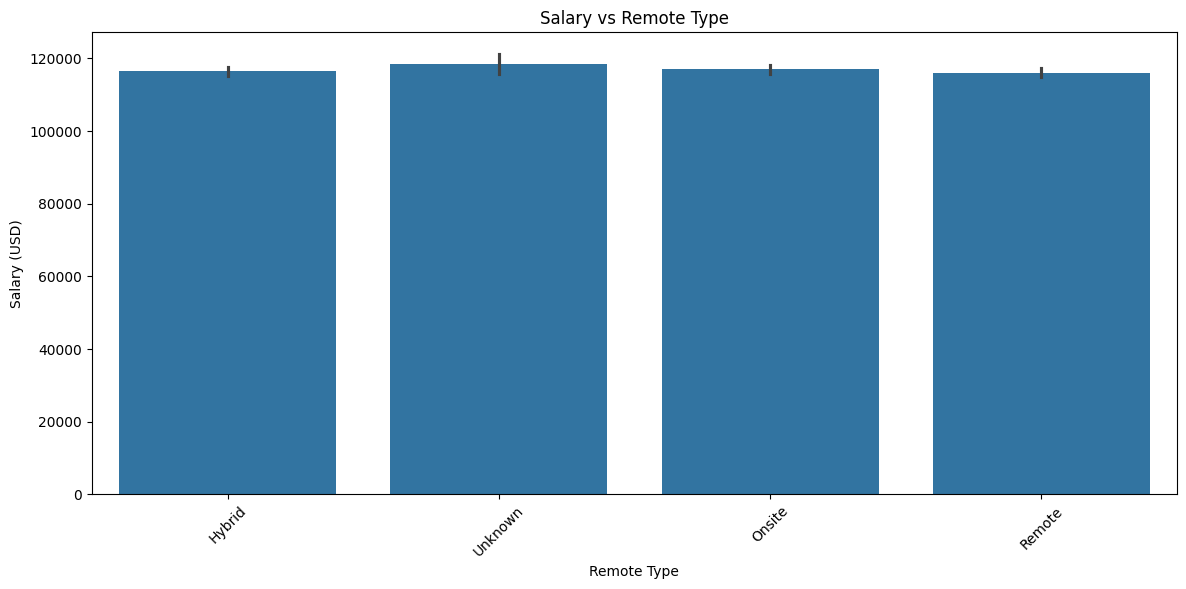

In [ ]:
# salary vs remote type
plt.figure(figsize=(14,6))

sns.barplot(
          data=df,
          x = 'Remote Type',
          y= 'Salary (USD)',
          )

plt.xticks(rotation=45)
plt.title("Salary vs Remote Type")
plt.show()

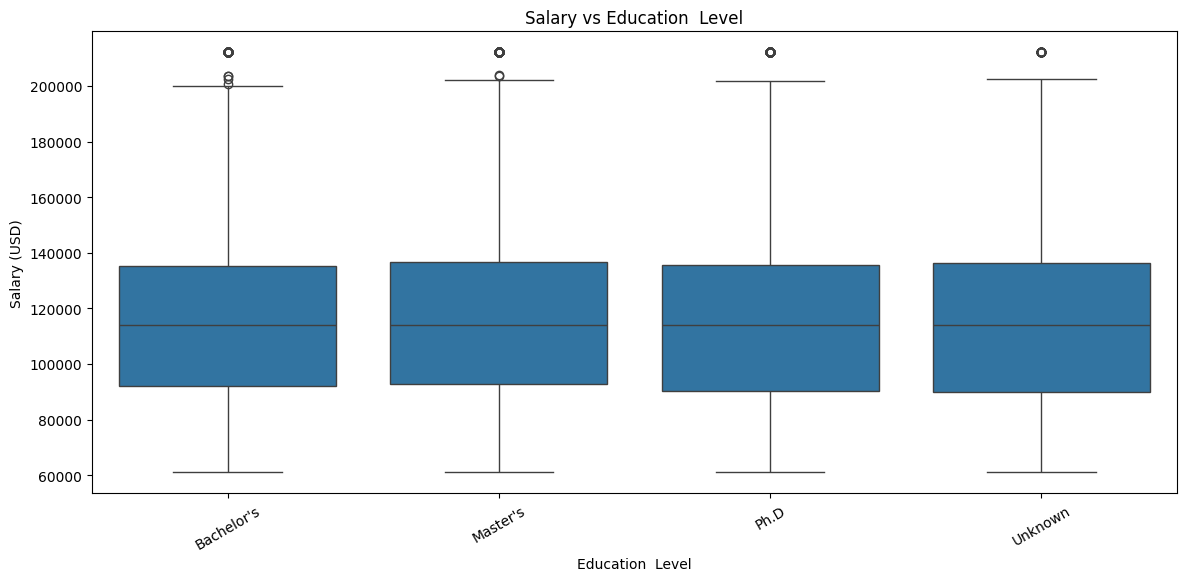

In [ ]:
# salary vs educational level
plt.figure(figsize=(14,6))
sns.boxplot(
    data = df,
    x = 'Education  Level',
    y = 'Salary (USD)'
)

plt.xticks(rotation=30)
plt.title("Salary vs Education  Level")
plt.show()

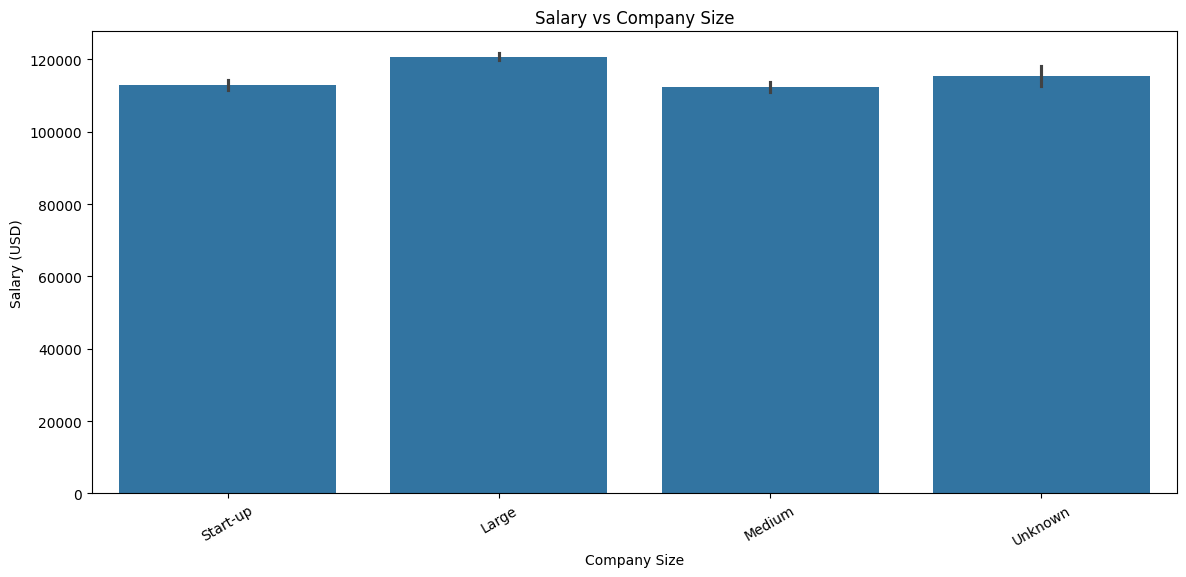

In [ ]:
# salary vs company size
plt.figure(figsize=(14,6))
sns.barplot(
    data = df,
    x = 'Company Size',
    y = 'Salary (USD)'
)

plt.xticks(rotation=30)
plt.title("Salary vs Company Size")
plt.show()

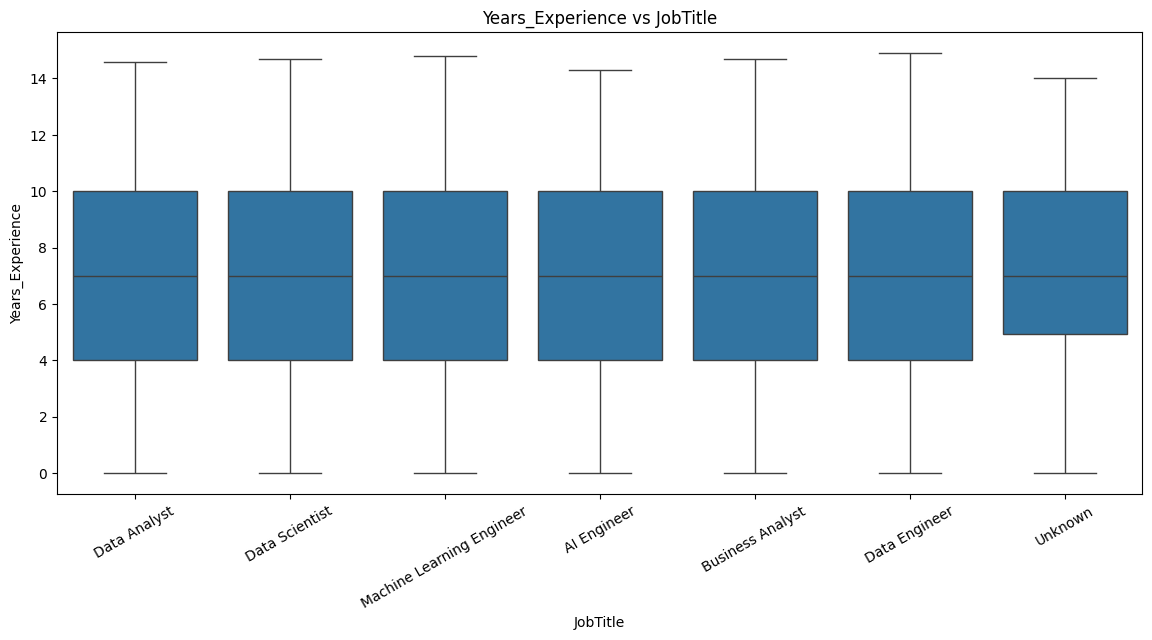

In [ ]:
# experience vs job title
plt.figure(figsize=(14,6))
sns.boxplot(
    data = df,
    x = 'JobTitle',
    y = 'Years_Experience'
)

plt.xticks(rotation=30)
plt.title("Years_Experience vs JobTitle")
plt.show()

Categorical - Categorical

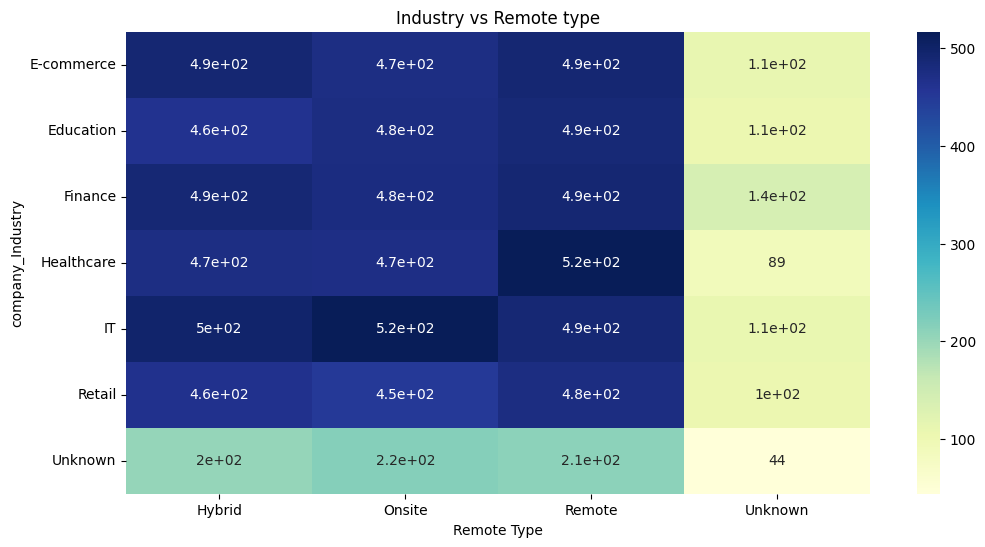

In [ ]:
industry = pd.crosstab(df['company_Industry'], df['Remote Type'])

plt.figure(figsize=(12,6))

sns.heatmap(
    industry,
    annot=True,
    cmap='YlGnBu'
)

plt.title("Industry vs Remote type")
plt.show()

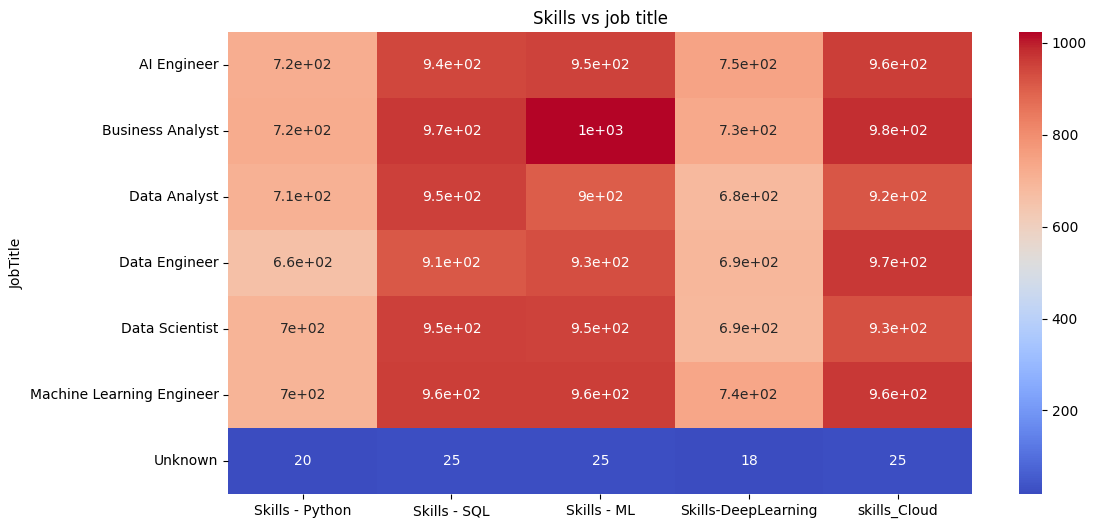

In [ ]:
# skills vs job title
skill_cols = [
    'Skills - Python',
    'Skills - SQL',
    'Skills - ML',
    'Skills-DeepLearning',
    'skills_Cloud'
]

job_skills = df.groupby("JobTitle")[skill_cols].sum()

plt.figure(figsize=(12,6))

sns.heatmap(
    job_skills,
    annot=True,
    cmap='coolwarm'
)

plt.title("Skills vs job title")
plt.show()

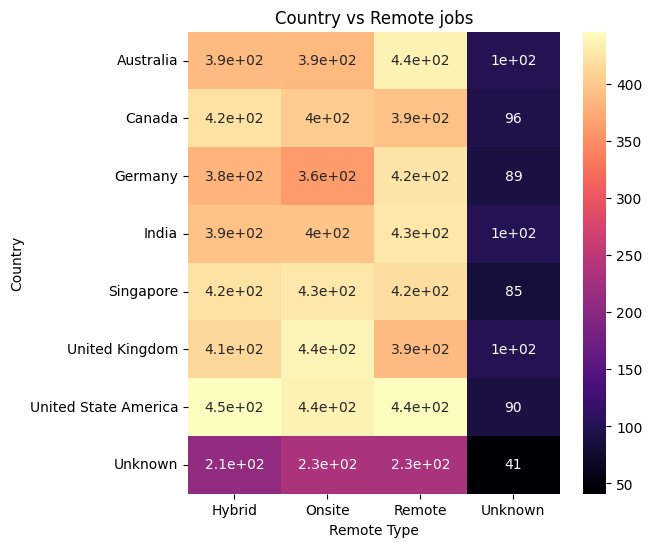

In [ ]:
# country vs remote jobs
country = pd.crosstab(
    df['Country'],
    df['Remote Type']
)

plt.figure(figsize=(6,6))

sns.heatmap(
    country,
    annot=True,
    cmap='magma'
)

plt.title("Country vs Remote jobs")
plt.show()

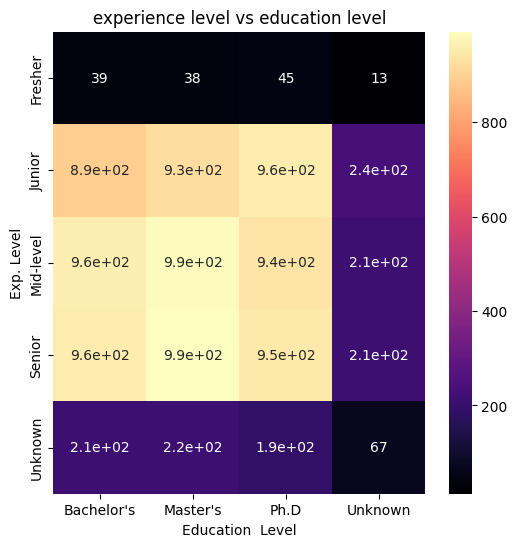

In [ ]:
# experience level vs education level
experience = pd.crosstab(
    df['Exp. Level'],
    df['Education  Level']
)

plt.figure(figsize=(6,6))

sns.heatmap(
    experience,
    annot=True,
    cmap='magma'
)

plt.title("experience level vs education level")
plt.show()

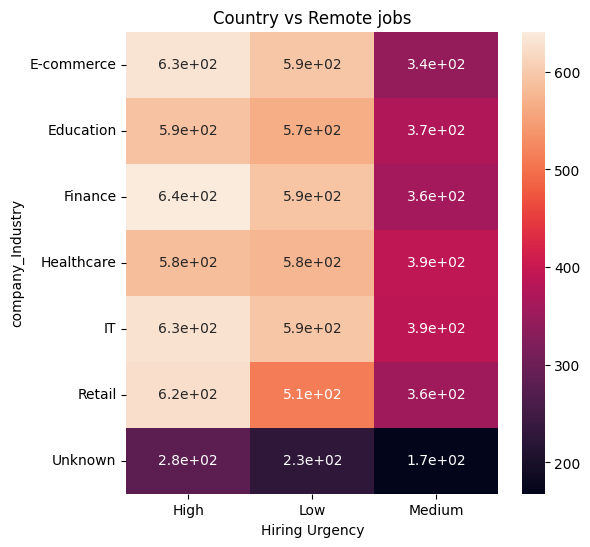

In [ ]:
# hiring urgency vs industry
hiring_urgency = pd.crosstab(
    df['company_Industry'],
    df['Hiring Urgency']
)

plt.figure(figsize=(6,6))

sns.heatmap(
    hiring_urgency,
    annot=True,
    cmap='rocket'
)

plt.title("Country vs Remote jobs")
plt.show()

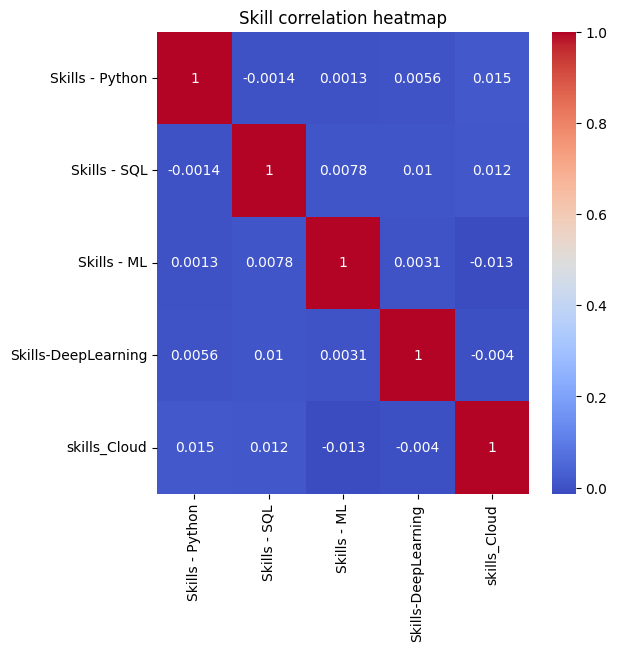

In [ ]:
# skill vs skill (heatmap)
skill = df[skill_cols].corr()

plt.figure(figsize=(6,6))

sns.heatmap(
    skill,
    annot=True,
    cmap='coolwarm'
)

plt.title("Skill correlation heatmap")
plt.show()

MULTIVARIATE ANALYSIS

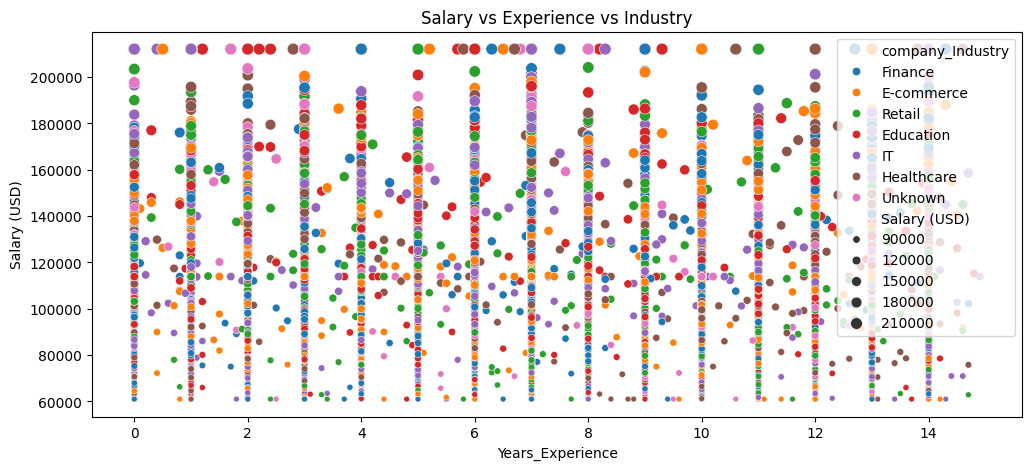

In [ ]:
# salary vs experience vs industry
plt.figure(figsize=(12,5))

sns.scatterplot(
    data = df,
    x = 'Years_Experience',
    y = 'Salary (USD)',
    hue = 'company_Industry',
    size = 'Salary (USD)'
)

plt.title("Salary vs Experience vs Industry")
plt.show()

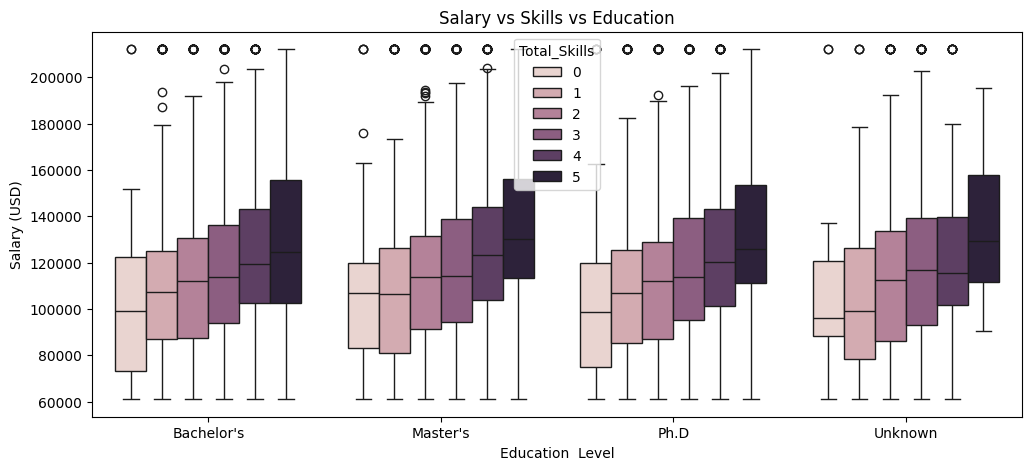

In [ ]:
# salary vs skills vs education
df['Total_Skills'] = df[skill_cols].sum(axis=1)
plt.figure(figsize=(12,5))

sns.boxplot(
    data = df,
    x = 'Education  Level',
    y = 'Salary (USD)',
    hue = 'Total_Skills'
)

plt.title("Salary vs Skills vs Education")
plt.show()

Remote Type                  Hybrid         Onsite         Remote  \
Country                                                             
Australia             115154.035347  119296.174223  116987.910920   
Canada                117680.953791  115293.009926  118945.693528   
Germany               112357.228403  116915.763158  117708.946934   
India                 115952.579949  115169.503157  115181.734155   
Singapore             118918.431280  117776.613583  113945.279904   
United Kingdom        116094.742754  116486.113014  114448.158740   
United State America  117417.131726  117181.073968  116364.943820   
Unknown               118182.875000  117909.687768  113541.968615   

Remote Type                 Unknown  
Country                              
Australia             119228.845000  
Canada                128936.065104  
Germany               118283.036517  
India                 111426.455882  
Singapore             117644.023529  
United Kingdom        116726.556931  
Unite

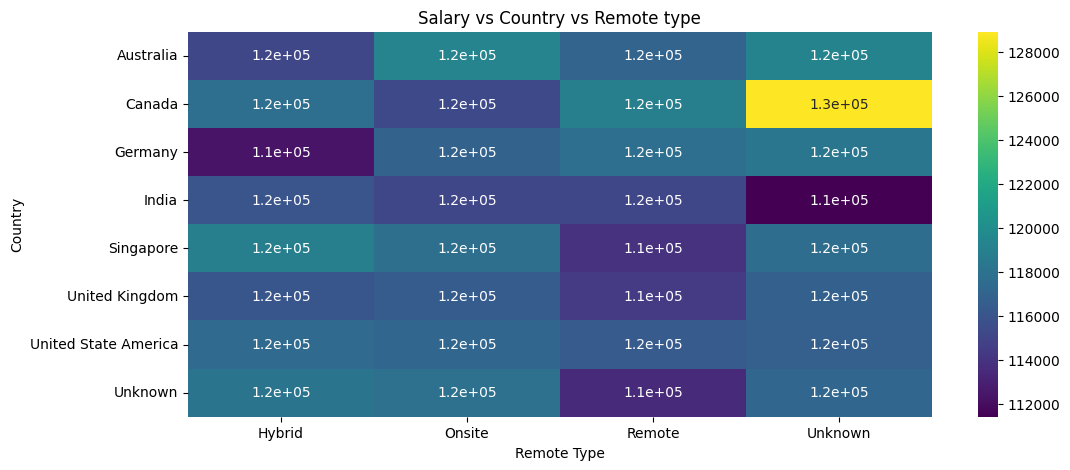

In [ ]:
# salary vs country vs remote type
pivot_salary = pd.pivot_table(
    df,
    values = 'Salary (USD)',
    index='Country',
    columns='Remote Type',
    aggfunc='mean'
)

print(pivot_salary)

plt.figure(figsize=(12,5))

sns.heatmap(
    pivot_salary,
    annot = True,
    cmap='viridis'
)

plt.title("Salary vs Country vs Remote type")
plt.show()

Remote Type                  Hybrid         Onsite         Remote  \
Country                                                             
Australia             115154.035347  119296.174223  116987.910920   
Canada                117680.953791  115293.009926  118945.693528   
Germany               112357.228403  116915.763158  117708.946934   
India                 115952.579949  115169.503157  115181.734155   
Singapore             118918.431280  117776.613583  113945.279904   
United Kingdom        116094.742754  116486.113014  114448.158740   
United State America  117417.131726  117181.073968  116364.943820   
Unknown               118182.875000  117909.687768  113541.968615   

Remote Type                 Unknown  
Country                              
Australia             119228.845000  
Canada                128936.065104  
Germany               118283.036517  
India                 111426.455882  
Singapore             117644.023529  
United Kingdom        116726.556931  
Unite

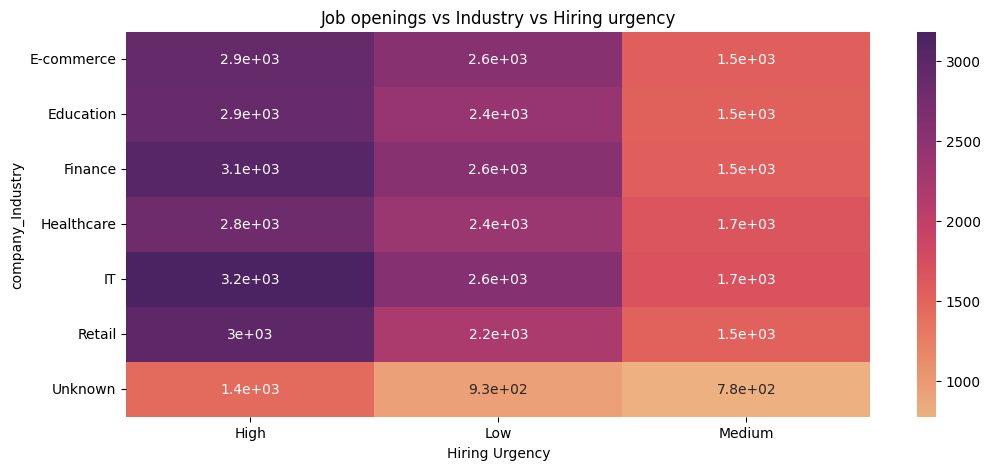

In [ ]:
# job openings vs industry vs hiring urgency
pivot_jobs = pd.pivot_table(
    df,
    values = 'Job Openings',
    index='company_Industry',
    columns='Hiring Urgency',
    aggfunc='sum'
)

print(pivot_salary)

plt.figure(figsize=(12,5))

sns.heatmap(
    pivot_jobs,
    annot = True,
    cmap='flare'
)

plt.title("Job openings vs Industry vs Hiring urgency")
plt.show()

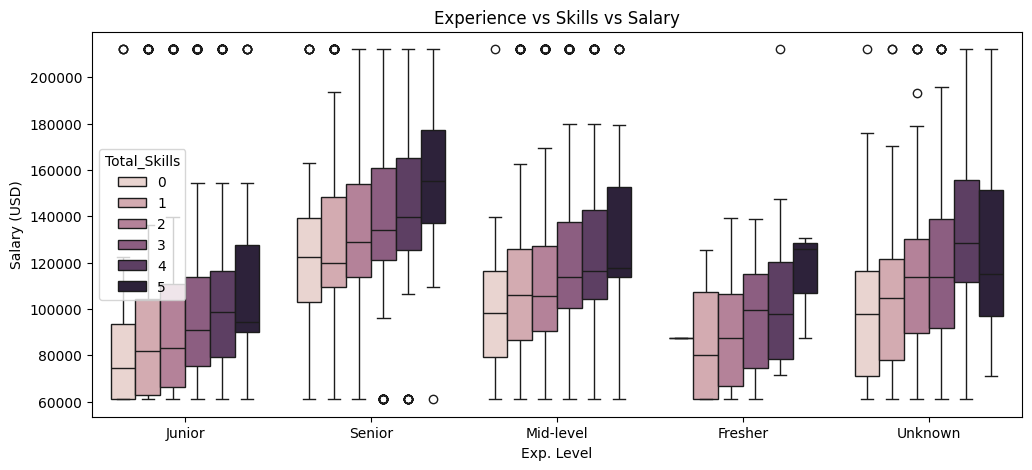

In [ ]:
# experience vs skills vs salary
plt.figure(figsize=(12,5))

sns.boxplot(
    data = df,
    x = 'Exp. Level',
    y = 'Salary (USD)',
    hue = 'Total_Skills'
)

plt.title("Experience vs Skills vs Salary")
plt.show()

In [ ]:
# skills combination vs salary
combo_salary = df.groupby(skill_cols)['Salary (USD)'].mean().sort_values(ascending=False)
combo_salary.head(10)

Skills - Python  Skills - SQL  Skills - ML  Skills-DeepLearning  skills_Cloud
1                1             1            1                    1               131501.292029
0                0             1            1                    1               131406.242537
1                0             1            1                    1               130822.299611
0                1             1            1                    1               130689.506111
                 0             1            1                    0               128567.683852
1                1             1            1                    0               127385.852881
                 0             1            1                    0               126091.976250
0                1             1            1                    0               121516.165796
1                0             0            1                    1               120322.974868
0                0             1            0                    1               119787.908523
Name: Salary (USD), dtype: float64

Country               Australia         Canada        Germany          India  \
company_Industry                                                               
E-commerce        118047.483553  117202.712500  113450.592742  113963.518868   
Education         120143.088710  116612.612299  117710.536096  114906.092500   
Finance           115398.572870  114365.940104  114475.302381  112349.248756   
Healthcare        114375.944444  121187.015021  115153.000000  111085.043011   
IT                117891.530914  114973.554847  121969.295918  116220.972107   
Retail            118155.432540  121834.437500  113393.760638  117504.901478   
Unknown           116383.652174  121697.447368  114109.838889  126498.449324   

Country               Singapore  United Kingdom  United State America  \
company_Industry                                                        
E-commerce        118824.809211   110706.910526         116109.933402   
Education         114729.658072   110473.121591         1187

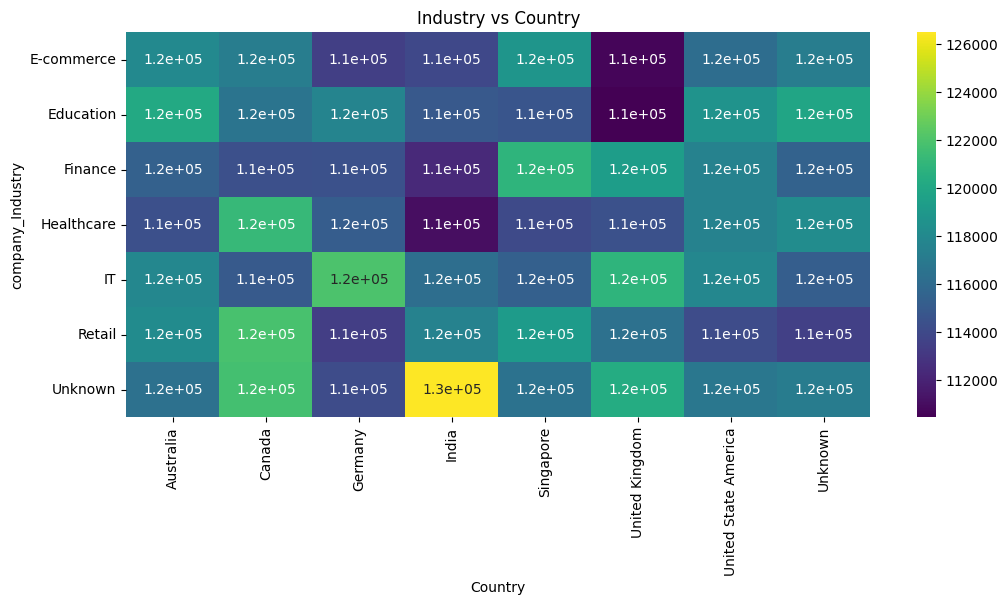

In [ ]:
# industry + country
pivot_country = pd.pivot_table(
    df,
    values = 'Salary (USD)',
    index='company_Industry',
    columns='Country',
    aggfunc='mean'
)

print(pivot_country)

plt.figure(figsize=(12,5))

sns.heatmap(
    pivot_country,
    annot = True,
    cmap='viridis'
)

plt.title("Industry vs Country")
plt.show()

In [ ]:
# year + month - hiring trend


In [ ]:
# skills clustering using pca


In [ ]:
# correlation heatmap


In [ ]:
num_cols = [
    'Years_Experience',
    'Salary (USD)',
    'Job Openings',
    'Total_Skills'
]

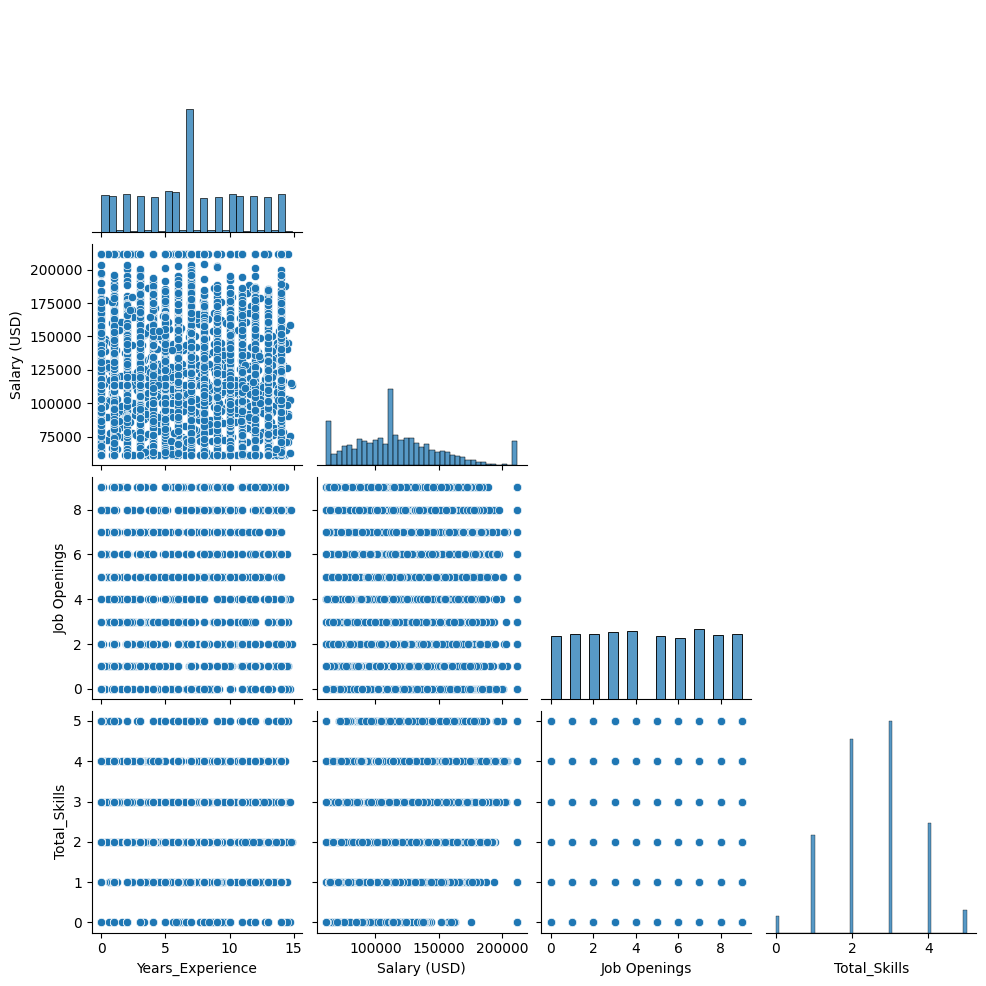

In [ ]:
# pairplot for key features
sns.pairplot(
    df[num_cols],
    corner=True
)

plt.show()

In [ ]:
# experience + education


In [ ]:
# remote + skills - salary interaction
